Creating visualizations...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile



Top 5 Combined Scores:
----------------------------------------
File: A_picture_of_a_plane_is_flying_in_the_air__1c54807909.png
Score: 0.9054
PSNR: 34.2408
SSIM: 0.9534
LPIPS: 0.0116
CLIP: 0.9521
----------------------------------------
File: A_formation_of_birds_in_a_sky_at_sunset__9ca6fcb7a4.png
Score: 0.9045
PSNR: 34.7138
SSIM: 0.9658
LPIPS: 0.0212
CLIP: 0.9345
----------------------------------------
File: A_propeller_plane_flying_through_a_gray_sky__ee598a2a23.png
Score: 0.9026
PSNR: 33.8072
SSIM: 0.9693
LPIPS: 0.0221
CLIP: 0.9589
----------------------------------------
File: A_row_of_birds_are_flying_against_a_blue_sky__b01b9ec552.png
Score: 0.9024
PSNR: 33.4364
SSIM: 0.9617
LPIPS: 0.0181
CLIP: 0.9732
----------------------------------------
File: An_airplane_flying_through_a_blue_sky_next_to_a_he_6a8ccab6b0.png
Score: 0.9008
PSNR: 34.0254
SSIM: 0.9765
LPIPS: 0.0307
CLIP: 0.9496
----------------------------------------

Bottom 5 Combined Scores:
--------------------------------

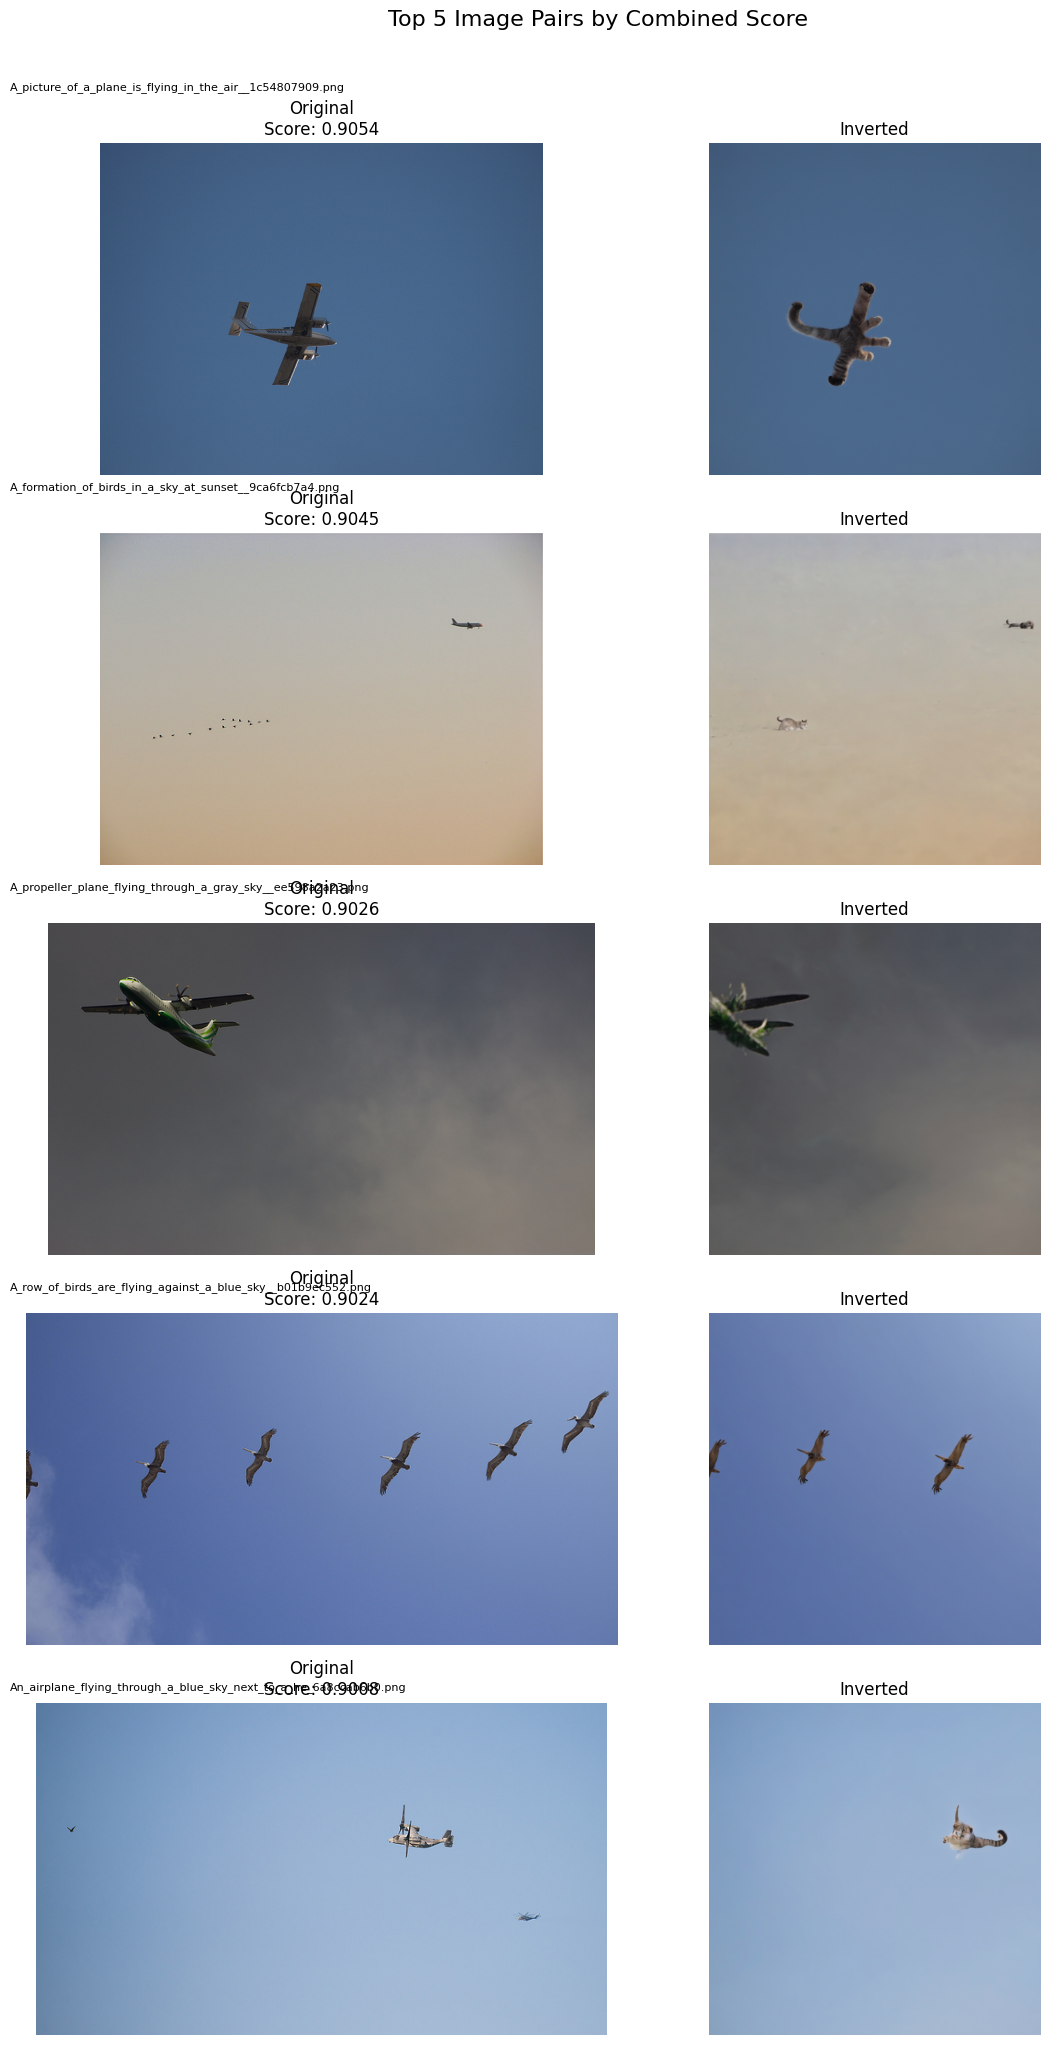

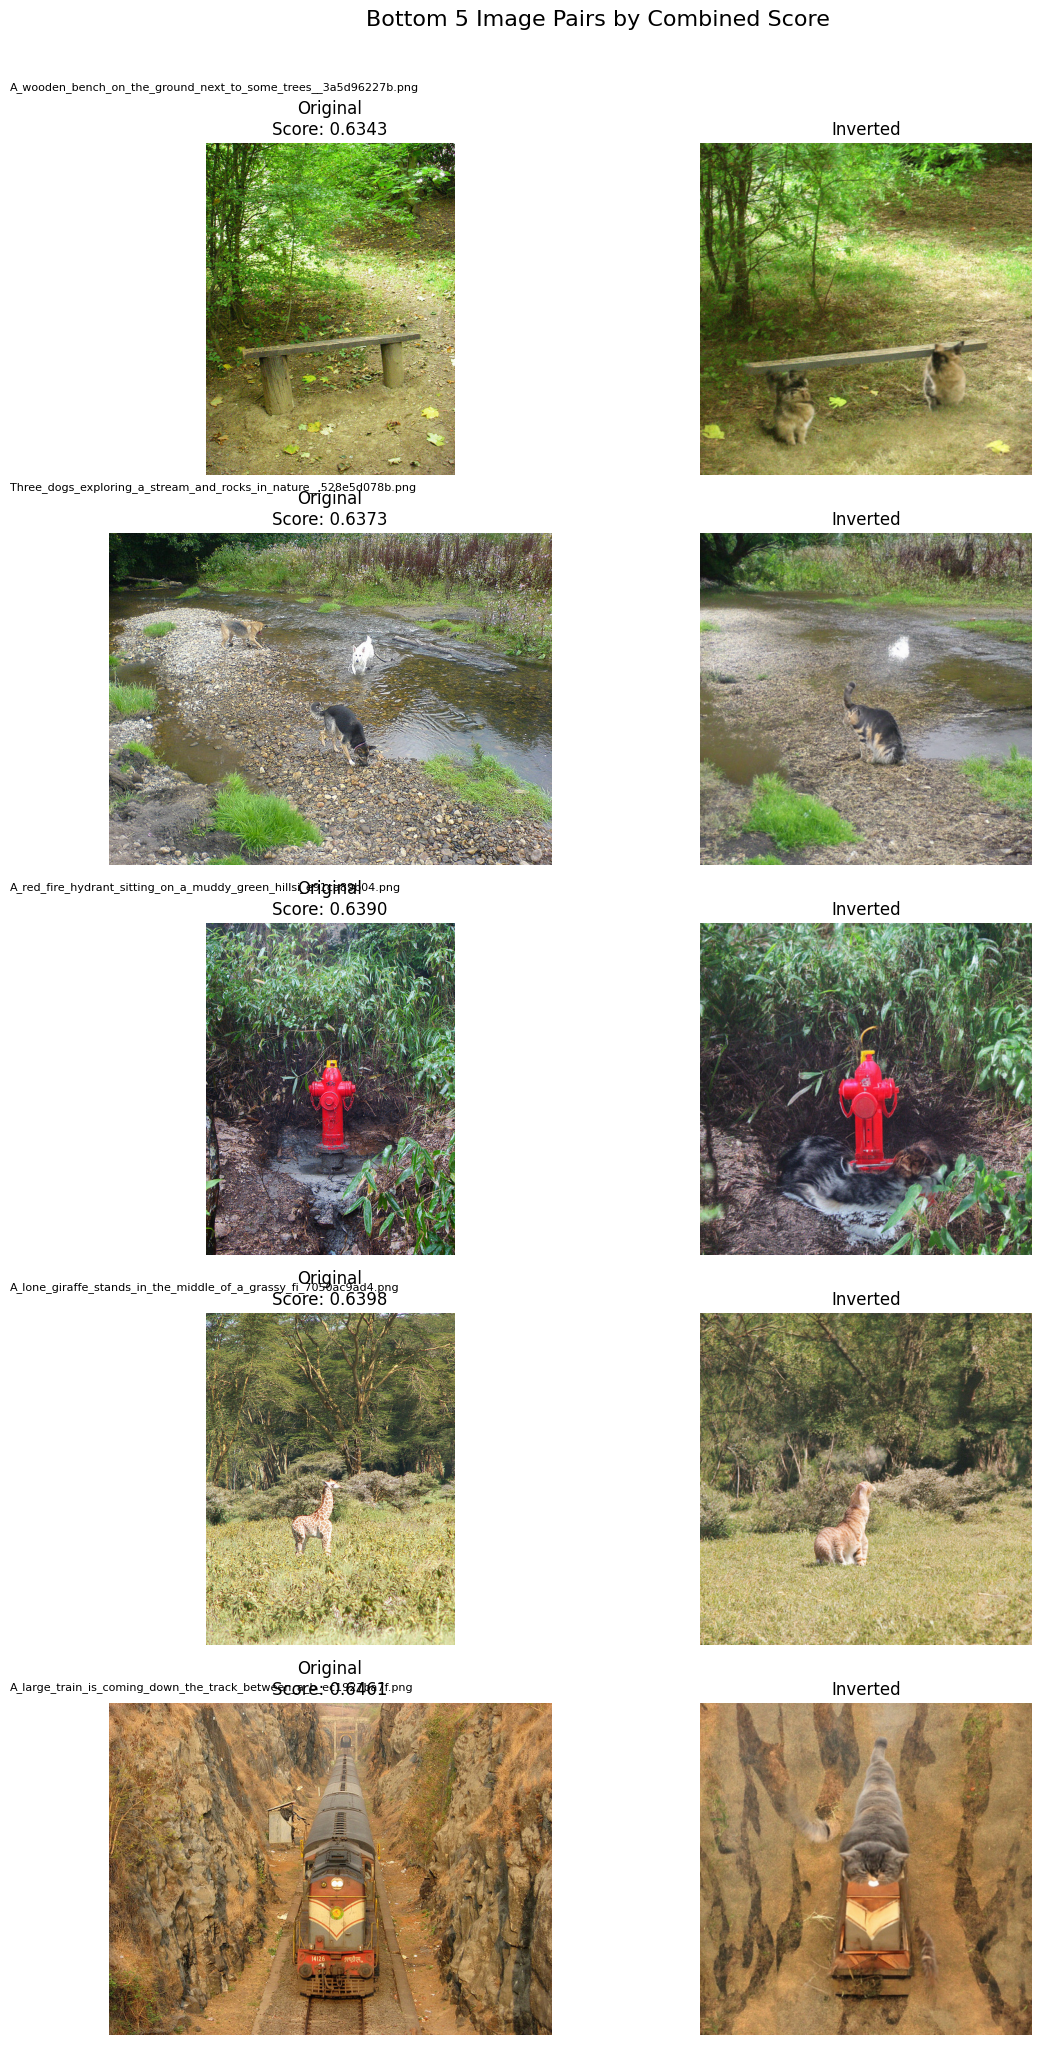

In [2]:
import json
import cv2
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
from pathlib import Path

def load_jsonl(file_path):
    """Load JSONL file and return list of dictionaries."""
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def get_inverted_path(fake_path):
    """Convert fake image path to inverted image path."""
    return fake_path.replace('/real/', '/inv_real/')

def display_image_pairs(image_pairs, scores, title):
    """Display image pairs in a grid with their scores."""
    n_pairs = len(image_pairs)
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4*n_pairs))
    fig.suptitle(title, fontsize=16, y=1.02)
    
    for idx, (fake_path, inv_path, score) in enumerate(image_pairs):
        # Read images
        fake_img = cv2.imread(fake_path)
        inv_img = cv2.imread(inv_path)
        
        # Convert BGR to RGB
        fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)
        inv_img = cv2.cvtColor(inv_img, cv2.COLOR_BGR2RGB)
        
        # Display images
        axes[idx, 0].imshow(fake_img)
        axes[idx, 0].set_title(f'Original\nScore: {score:.4f}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(inv_img)
        axes[idx, 1].set_title('Inverted')
        axes[idx, 1].axis('off')
        
        # Add filename as text
        plt.figtext(0.01, 0.98 - (idx/n_pairs), 
                   os.path.basename(fake_path), 
                   fontsize=8, 
                   wrap=True)
    
    plt.tight_layout()
    return fig

def main():
    # Load JSONL file
    jsonl_path = "/shared/shashmi/inversion/new_metric/finally_metric/SD3_condtioned_image_real_inv_real_metrics.jsonl"
    data = load_jsonl(jsonl_path)
    
    # Sort data by combined score
    sorted_data = sorted(data, key=lambda x: x['metrics']['combined_score'])
    
    # Get top and bottom 5
    bottom_5 = sorted_data[:5]
    top_5 = sorted_data[-5:][::-1]  # Reverse to show highest first
    
    # Prepare image pairs and scores
    bottom_pairs = [(d['image_path'], 
                    get_inverted_path(d['image_path']), 
                    d['metrics']['combined_score']) for d in bottom_5]
    
    top_pairs = [(d['image_path'], 
                  get_inverted_path(d['image_path']), 
                  d['metrics']['combined_score']) for d in top_5]
    
    # Create visualizations
    print("Creating visualizations...")
    
    # Display top 5 pairs
    fig1 = display_image_pairs(top_pairs, 
                             [score for _, _, score in top_pairs],
                             'Top 5 Image Pairs by Combined Score')
    fig1.savefig('top_5_pairs.png', bbox_inches='tight', dpi=300)
    
    # Display bottom 5 pairs
    fig2 = display_image_pairs(bottom_pairs,
                             [score for _, _, score in bottom_pairs],
                             'Bottom 5 Image Pairs by Combined Score')
    fig2.savefig('bottom_5_pairs.png', bbox_inches='tight', dpi=300)
    
    # Print scores
    print("\nTop 5 Combined Scores:")
    print("-" * 40)
    for d in top_5:
        print(f"File: {os.path.basename(d['image_path'])}")
        print(f"Score: {d['metrics']['combined_score']:.4f}")
        print(f"PSNR: {d['metrics']['psnr']:.4f}")
        print(f"SSIM: {d['metrics']['ssim']:.4f}")
        print(f"LPIPS: {d['metrics']['lpips']:.4f}")
        print(f"CLIP: {d['metrics']['clip_similarity']:.4f}")
        print("-" * 40)
    
    print("\nBottom 5 Combined Scores:")
    print("-" * 40)
    for d in bottom_5:
        print(f"File: {os.path.basename(d['image_path'])}")
        print(f"Score: {d['metrics']['combined_score']:.4f}")
        print(f"PSNR: {d['metrics']['psnr']:.4f}")
        print(f"SSIM: {d['metrics']['ssim']:.4f}")
        print(f"LPIPS: {d['metrics']['lpips']:.4f}")
        print(f"CLIP: {d['metrics']['clip_similarity']:.4f}")
        print("-" * 40)
    
    print("\nVisualization saved as 'top_5_pairs.png' and 'bottom_5_pairs.png'")

if __name__ == "__main__":
    main()